# Machine Learning

In this section, I will apply regression models to predict trending weeks of memes. XGBoost and Random Forest will be used as models. The reason is explained in the report.

In [3]:
#First, clean the data similar to the Exploratory Data Analysis notebook. Further explanations were given there and in report.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_main=pd.read_csv('/content/meme_lifespan_data_raw.csv')
df_clean=df_main[~((df_main["weeks_of_trends"] == 0) | (df_main["weeks_of_trends"] == 235))]
df_clean=df_clean.rename(columns={'Unnamed: 0':'name'})
df_clean=df_clean.dropna(subset=["weeks_of_trends"])

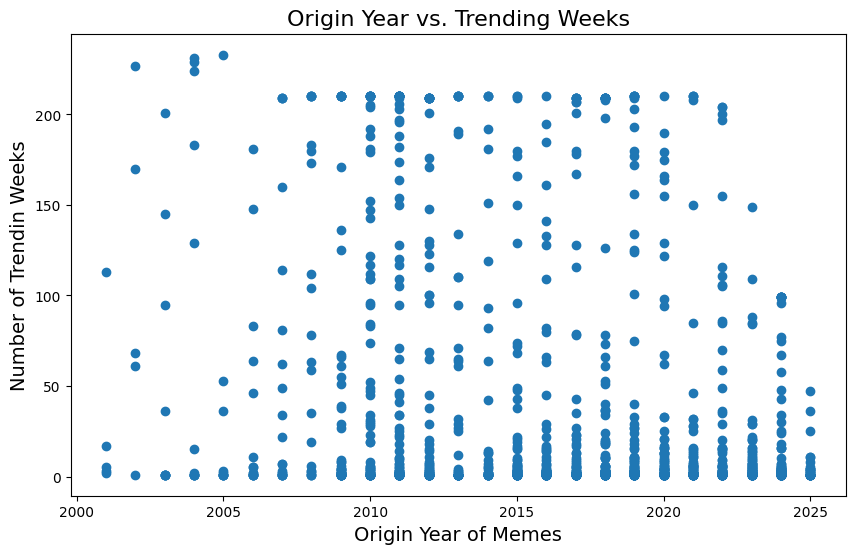

In [4]:
fig, ax =plt.subplots(figsize=(10,6))

ax.scatter(df_clean[df_clean['origin_year']>2000]["origin_year"],df_clean[df_clean['origin_year']>2000]['weeks_of_trends'])

plt.xlabel("Origin Year of Memes",fontsize=14)
plt.ylabel("Number of Trending Weeks",fontsize=14)
plt.title("Origin Year vs. Trending Weeks", fontsize=16)

plt.show()

As we can see there is no clear linear relationship between two features. Hence, we cannot use simple linear regression model. We need to opt for XGBoost or Random Forest models for better accuracy. The origin_platfrom will also be used to train models. Therefore, label encoding is needed.

# Label Encoding

In [5]:
#Label encoding of origin_platform

df_clean['origin_platform']=df_clean['origin_platform'].astype('category').cat.codes
#starts from 0 and assigns -1 for NaN values
df_clean.head()

,name,origin_year,origin_platform,weeks_of_trends
0,pedobear,2003,0,201.0
1,tinaecmusic,2007,28,7.0
2,raptor jesus,2005,0,233.0
3,when you see it,2008,-1,210.0
4,charlie bit my finger,2007,28,160.0


# Random Forest Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score



X=df_clean[["origin_year"]]
y=df_clean['weeks_of_trends']

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

#We need to find the best number of estimators and maxiumum depth parameters of random forest model

max_r2=0
min_MSE=10000
for n_estimator in range(90,120):
  for depth in range(1,11):
    model=RandomForestRegressor(n_estimators=n_estimator,max_depth=depth,random_state=42)
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)

    current_r2=r2_score(y_test,prediction)
    current_MSE=mean_absolute_error(y_test,prediction)
    if current_r2>max_r2:
      max_r2=current_r2
      min_MSE=current_MSE
      best_model=model


print("Best R2 is:",max_r2)
print("Best MSE is:", min_MSE)


Best R2 is: 0.05693638134091761
Best MSE is: 51.779834594314295


# Extreme Gradient Boosting Regression (XGBoost)

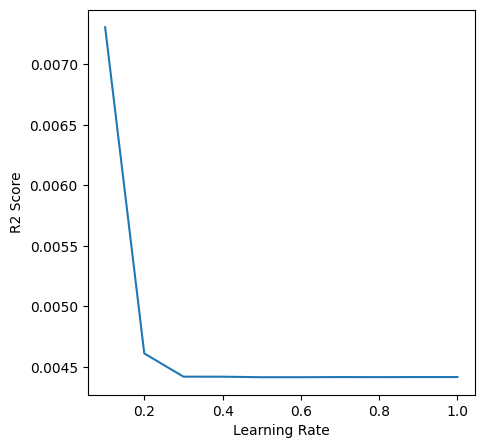

Best R2 is: 0.007306516280218278
Best MSE is: 51.90511063718984


In [19]:
import xgboost as xgb

#we got the X and y from previous code block

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

max_r2=0
min_MSE=10000
r2_list=[]
learning_rate_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
for rate in learning_rate_list:
  model=xgb.XGBRegressor(n_estimators=100,learning_rate=rate,max_depth=5,random_state=42)
  model.fit(X_train,y_train)
  prediction=model.predict(X_test)

  current_r2=r2_score(y_test,prediction)
  current_MSE=mean_absolute_error(y_test,prediction)

  r2_list.append(current_r2)
  if current_r2>max_r2:
    max_r2=current_r2
    min_MSE=current_MSE
    best_model=model



fig,ax=plt.subplots(figsize=(5,5))

ax.plot(learning_rate_list,r2_list)

plt.xlabel("Learning Rate")
plt.ylabel("R2 Score")
plt.show()

print("Best R2 is:",max_r2)
print("Best MSE is:", min_MSE)